In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd

DIR = r'../data/dirty/dirty_df.csv'

data = pd.read_csv(DIR, index_col = 0)[['ROA', 'AAGR', 'DY', 'P/E', 'beta']]
data.head()


,ROA,AAGR,DY,P/E,beta
ALIOR,0.009196,0.582233,0.000000,4.404444,1.463940
ALLEGRO,0.012178,0.539843,0.000000,45.460689,0.772608
ASSECOPOL,0.057254,0.146215,0.045966,4.617202,0.559913
BENEFIT,0.137899,1.577394,0.028244,12.357455,0.781190
BUDIMEX,0.063130,0.381019,0.076436,15.237392,1.075289


In [2]:
from src.model_implementation import create_pipeline

xticks = np.arange(1, 10, 1)
yticks_s = []
for i in xticks:
    pipeline = create_pipeline(i).fit(data)
    yticks_s.append(pipeline.named_steps['kmeans'].inertia_)

c:\Users\Wiktor\miniconda3\envs\lic_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Wiktor\miniconda3\envs\lic_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Wiktor\miniconda3\envs\lic_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows 

In [3]:
inercja = pd.DataFrame(yticks_s, index = xticks)
inercja['dynamika'] = inercja.diff()
print(inercja)

            0   dynamika
1  150.000000        NaN
2  117.526150 -32.473850
3   90.939067 -26.587083
4   76.986357 -13.952710
5   61.206800 -15.779557
6   50.335153 -10.871647
7   41.121229  -9.213925
8   36.236120  -4.885108
9   30.796745  -5.439376


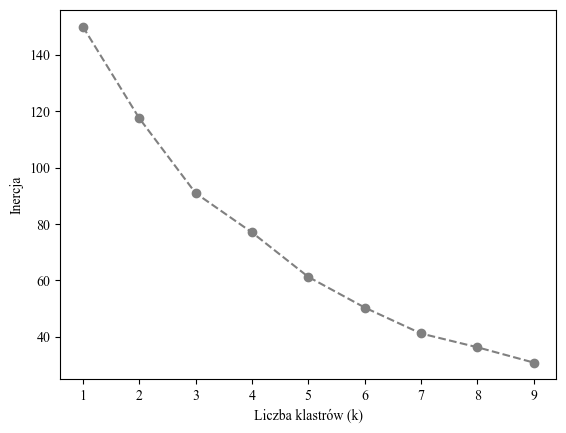

In [4]:
from src.processing import set_plot_style, set_plot_font, save_chart
set_plot_font()
plt.plot(xticks, yticks_s, color = 'grey', marker = 'o', linestyle = '--')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inercja')
save_chart('elbow_method')

In [5]:
pipeline = create_pipeline(clusters = 3)
labels = pipeline.fit_predict(data)

c:\Users\Wiktor\miniconda3\envs\lic_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [9]:
data['label'] = labels
print(data['label'].sort_values())

ALIOR         0
CCC           0
JSW           0
ENEA          0
KGHM          0
PKOBP         0
PEKAO         0
MILLENNIUM    0
PGE           0
TAURONPE      0
SANPL         0
PZU           0
PEPCO         1
MBANK         1
ALLEGRO       1
ZABKA         1
LPP           2
KRUK          2
DINOPL        2
KETY          2
BENEFIT       2
BUDIMEX       2
CDPROJEKT     2
CYFRPLSAT     2
ASSECOPOL     2
ORANGEPL      2
PKNORLEN      2
RAINBOW       2
SYNEKTIK      2
XTB           2
Name: label, dtype: int32
